# Graphene Calculations

The purpose of this notebook is to demonstrate a calculation of a graphene system and the extraction of the real-space Hamiltonian.

## Imports

In [39]:
from ase import Atoms
from ase.calculators.openmx import OpenMX
from kodiak_openmx import OpenMXScfout, run_openmx, read_openmx_band, get_job_status

import os
from pathlib import Path
# import pbs_tools as pbs
import numpy as np

## Filespace Parameters

In [40]:
prefix = 'graphene'

homedir = os.getcwd()

# calcs is the symlink to a storage directory you prepared
# Each OpenMX calculation should have its own workdir. Input and output files will be stored here
workdir = os.path.join( '..', '..', 'calcs', 'examples',
                      'graphene')

Path( workdir ).mkdir( exist_ok=True, parents=True )

os.path.exists( workdir )
print(workdir)

../../calcs/examples/graphene


## Define the Periodic System

In [41]:
a = 2.46
vacuum = 15.0

cell = [
    [ a/2,  np.sqrt(3)*a/2, 0.0],
    [-a/2,  np.sqrt(3)*a/2, 0.0],
    [ 0.0,  0.0,            vacuum]
]

positions = [
    [0.0, 0.0, 0.0],
    [0.0, a/np.sqrt(3), 0.0]
]

atoms = Atoms(
    "C2",
    positions=positions,
    cell=cell,
    pbc=[True, True, True]
)

definition_of_atomic_species = [
    ['C', 'C6.0-s2p2d1', 'C_PBE19']
]

print(f'Initial path: {homedir}')

Initial path: /ion/home/blaire/Research/kodiak-openmx/notebooks/examples


We also define some parameters for a validation step. We will use the real-space Hamiltonian and the overlap matrix to recreate the band structure and compare it to a band structure calculated using OpenMX.

In [42]:
# Not needed for the real-space Hamiltonian, but we'll use it for validation
band_nkpath=3

band_kpath=[
    [
        60,
        0.0, 0.0, 0.0,      # Gamma
        2/3, 1/3, 0.0,      # K
        "G", "K"
    ],
    [
        60,
        2/3, 1/3, 0.0,      # K
        0.5, 0.0, 0.0,      # M
        "K", "M"
    ],
    [
        60,
        0.5, 0.0, 0.0,      # M
        0.0, 0.0, 0.0,      # Gamma
        "M", "G"
    ]
]


## Prepare an `OpenMX` Input File

In [43]:
# omx_command isn't actually used to run the calculation
# This is needed so we don't get an ASE error about a missing configuration
#   for OpenMX
omx_command = f'command="openmx {prefix}.dat > {prefix}.out",'

# We create an ASE OpenMX calculator
calc = OpenMX(
    data_path='/usr/local/apps/openmx/3.9/DFT_DATA19',
    directory=workdir, # this is where input/output are
    system_currentdirectory='./',
    command=omx_command,
    label=prefix,
    definition_of_atomic_species = definition_of_atomic_species,
    scf_kgrid=(18, 18, 1),
    scf_xctype='GGA-PBE',
    scf_spinpolarization='off',
    scf_eigenvaluesolver='dc', # This is for a band structure (for validation)
    scf_maxiter=100,
    scf_energycutoff=150,
    hs_fileout=True, # we need this to get the real-space Hamiltonian
    band_dispersion=True, # This is for a band structure (for validation)
    band_nkpath= band_nkpath, # Number of k-path segments for band structure
    band_kpath = band_kpath,
)

# Associate the calculator with the atoms object
atoms.calc = calc

# We do not use atoms.get_potential_energy() to run OpenMX, but rather,
#   we use some custom code in the kodiak_openmx package (not this
#   cell)
# energy = atoms.get_potential_energy()

# Write the OpenMX input file
calc.write_input(atoms)

## Run `OpenMX`

`run_openmx()` launches a calculation on Kodiak via PBS. It's designed to refrain from launching a calculation if:
1. a previous execution of the following cell already has queued a job,
2. that job is in progress, or
3. the previously-launched job is complete.

`run_openmx()` can track the status of a previously-queued job because we create a status (`statusFile.txt`) that indicate when a job is queued, started, and ended.

If you need to re-run `OpenMX`, delete the status file, or delete the entire work directory.

In [44]:
# Run OpenMX
run_openmx( prefix, workdir, verbose=True )

has_status = os.path.exists( os.path.join( workdir,
                                           'scf_status.txt' )
                            )

print(f'Found status file: {has_status}')

Job ID: 3997916
Status file detected. Calculation skipped.
Found status file: True


## Post-processing

The following code checks to see whether the job is done. If the job is not done, we do not go on to the post-processing.

In [45]:

if has_status:
    job_status = get_job_status( os.path.join( workdir,
                                               'scf_status.txt'),
                                 os.path.join( workdir,
                                               'outputFile.std') )
    print(f'Job status: {job_status}')
else:
    print('The job does not yet have a status file. Try running the above code blocks to launch the calculation.')

# Prevent post-processing if the job is not done
assert job_status == 'done', "Job is not yet done. We will avoid post-processing."

# Parse the Hamiltonian
scf = OpenMXScfout( os.path.join( workdir,
                                  f'{prefix}.scfout') )


Job status: done


Next, we may wish to inspect some of the results contained within the `scf` object:

In [46]:
# print the real-space Hamiltonian (it's a sparse matrix)
print(scf.H_R) 

print("atomnum =", scf.atomnum)
print("Total_NumOrbs =", scf.Total_NumOrbs)
print("nbasis =", scf.nbasis)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 676 stored elements and shape (26, 26)>
  Coords	Values
  (0, 0)	-1.307363181972237
  (0, 1)	1.0779082298371734
  (0, 2)	5.605764333629915e-13
  (0, 3)	1.8166369583881743e-05
  (0, 4)	-2.3682394478658852e-14
  (0, 5)	6.363699844857962e-11
  (0, 6)	2.9633876030370904e-05
  (0, 7)	1.2230927522023956e-14
  (0, 8)	0.4129289151558108
  (0, 9)	-4.134100962384368e-05
  (0, 10)	1.0562734823089948e-11
  (0, 11)	5.122911683236762e-15
  (0, 12)	-1.8957554823426174e-15
  (0, 13)	-1.3555903354735488
  (0, 14)	0.9757886889445301
  (0, 15)	7.585002138638282e-12
  (0, 16)	-1.9200644259734638e-05
  (0, 17)	-2.0360938321495894e-14
  (0, 18)	3.037871603578379e-11
  (0, 19)	-3.774661425810398e-05
  (0, 20)	1.6423707276407148e-14
  (0, 21)	0.36590272127175105
  (0, 22)	-2.1806759092231463e-05
  (0, 23)	-1.5391228656153055e-11
  (0, 24)	-2.623432850142492e-15
  :	:
  (25, 1)	-1.3119943609155177e-15
  (25, 2)	1.1472935907565287e-15
  (25, 3)	3.463

## Validation

We would like to validate the results to some extent.

### Is the Hamiltonian Hermitian?

In [47]:
# Convert sparse matrix to dense matrix
H = scf.H_R.toarray()

# Compute Hermiticity error
herm_diff = H - H.conj().T

# This is messy, but print it if you wish
# print("\nH - H†:")
# print(herm_diff)

# Maximum absolute deviation from Hermiticity
max_error = np.max(np.abs(herm_diff))

print(f"\nMaximum Hermiticity error: {max_error:e}")

# Boolean check
is_hermitian = np.allclose(H, H.conj().T)

print(f"Hermitian? {is_hermitian}")


Maximum Hermiticity error: 3.527951e-10
Hermitian? True


### Eigenvalues

In [48]:
from scipy.linalg import eigh

H = scf.H_R.toarray() # real-space Hamiltonain
S = scf.S_R.toarray() # real-space overlap matrix

# Solve the generalized eigenvalue problem
eigvals, eigvecs = eigh(H, S)

print("Eigenvalues (Hartree):")
print(eigvals)

print("Eigenvalues (eV):")
print(eigvals * 27.2114)

print("\n" + "="*20 + "\nFor a periodic system:\n")
for n in range(20):
    print(
        scf.H_R_rows[n],
        scf.H_R_cols[n],
        scf.H_R_cell_indices[n],
        scf.H_R_data[n]
    )

Eigenvalues (Hartree):
[-0.85872201 -0.41932325 -0.25294464 -0.25287223  0.16888548  0.16895224
  0.28660133  0.29341847  0.33451407  0.34145926  1.01492631  1.02134363
  1.02145735  1.48913223  1.48920256  1.74947595  1.74961997  2.06322124
  2.50626827  2.50632307  3.10341195  3.52382403  3.5254244   5.01577525
  5.01629749  6.68824612]
Eigenvalues (eV):
[-23.36702816 -11.41037265  -6.88297791  -6.88100752   4.59561025
   4.59742707   7.79882347   7.98432737   9.10259613   9.29158453
  27.61756573  27.79219011  27.79528446  40.52137287  40.5232866
  47.60568995  47.60960889  56.14313856  68.19906844  68.20055959
  84.44818388  95.88818528  95.9317336  136.48626653 136.50047765
 181.99654051]

For a periodic system:

0 0 0 -0.6476961372027521
0 1 0 0.08748680741998649
0 2 0 1.0191551531544948e-12
0 3 0 2.3419353373624596e-05
0 4 0 -1.5237091403443548e-14
0 5 0 5.204936358353336e-11
0 6 0 -2.9927750180474302e-06
0 7 0 9.40683286962914e-16
0 8 0 0.15646364632344484
0 9 0 -2.895892046091

### Band Structure Validation

In [52]:
#
# Reciprocal lattice vectors
#
B = scf.reciprocal_vectors()

#
# High-symmetry points in fractional coordinates
#
Gamma = np.array([0.0, 0.0, 0.0])

K = np.array([2/3, 1/3, 0.0])

M = np.array([0.5, 0.0, 0.0])

#
# Path segments
#
path = [
    (Gamma, K, 60),
    (K, M, 60),
    (M, Gamma, 60)
]

kdist = []

bands = []

cumulative_distance = 0.0

prev_kcart = None

for iseg, (kstart, kend, nk_segment) in enumerate(path):

    for t in np.linspace(
            0.0,
            1.0,
            nk_segment
    ):

        #
        # Fractional k-point
        #
        kfrac = (
            (1.0 - t) * kstart
            + t * kend
        )

        #
        # Cartesian k-point
        #
        kcart = (
            kfrac[0] * B[0]
            + kfrac[1] * B[1]
            + kfrac[2] * B[2]
        )

        #
        # Build cumulative path distance
        #
        if prev_kcart is not None:

            cumulative_distance += np.linalg.norm(
                kcart - prev_kcart
            )

        kdist.append(cumulative_distance)

        #
        # Bloch Hamiltonian
        #
        Hk = scf.Hk(kcart)

        Sk = scf.Sk(kcart)

        eigvals, eigvecs = eigh(Hk, Sk)

        bands.append(eigvals.real)

        prev_kcart = kcart.copy()

bands = np.array(bands)

kdist = np.array(kdist)

# The file containing band structure data ends in *.Band
bands_data = os.path.join( workdir, f'{prefix}.Band')

# Parse the OpenMX band structure results
k_openmx, bands_openmx, Ef_openmx = read_openmx_band(
    bands_data,
    B
)

# Align parser data to the Fermi level
bands = bands * 27.2114 - Ef_openmx

# Normalize the kpoints so that OpenMX bands can be plotted against
#   those based on the real-space H and S matrices
x_parser = kdist / np.max(kdist)
x_openmx = k_openmx / np.max(k_openmx)

# This is an offset I chose after the fact to make the reference data (OpenMX band structure)
# align vertically with that which we obtain from H_R and S_R
E_offset = -5 # [eV] A manual vertical offset to compare the bands

print(f'Fermi energy from OpenMX: {Ef_openmx}')


Fermi energy from OpenMX: -4.927134190835522


#### Visualize the Band structure

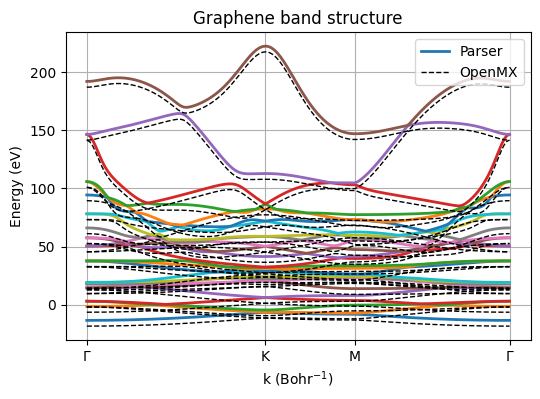

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

for n in range(bands.shape[1]):

    plt.plot(
        x_parser,
        bands[:, n] - E_offset,
        linewidth=2,
        label="Parser" if n == 0 else None
    )

#
# OpenMX reference bands
#
for n in range(bands_openmx.shape[1]):
    plt.plot(
        x_openmx,
        bands_openmx[:, n] - E_offset,
        "k--",
        linewidth=1,
        label="OpenMX" if n == 0 else None
    )

plt.xlabel("k (Bohr$^{-1}$)")
plt.ylabel("Energy (eV)")
plt.title("Graphene band structure")

nk1, nk2, nk3 = 60, 60, 60

tick_positions = [
    0.0,
    kdist[nk1 -1],
    kdist[nk1 + nk2 -1],
    kdist[-1]
]

tick_positions = np.array(tick_positions)
tick_positions /= np.max(kdist)

plt.xticks(
    tick_positions,
    [r"$\Gamma$", "K", "M", r"$\Gamma$"]
)

plt.legend()

plt.grid(True)

plt.show()


#### A zoomed-in Band Structure Plot

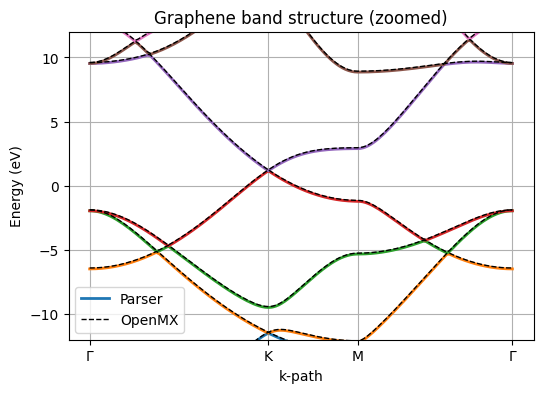

In [58]:
plt.figure(figsize=(6,4))

for n in range(bands.shape[1]):

    plt.plot(
        x_parser,
        bands[:, n],
        linewidth=2,
        label="Parser" if n == 0 else None
    )

for n in range(bands_openmx.shape[1]):

    plt.plot(
        x_openmx,
        bands_openmx[:, n] - E_offset,
        "k--",
        linewidth=1,
        label="OpenMX" if n == 0 else None
    )

plt.xticks(
    tick_positions,
    [r"$\Gamma$", "K", "M", r"$\Gamma$"]
)

plt.ylim(-12, 12)

plt.xlabel("k-path")
plt.ylabel("Energy (eV)")

plt.title("Graphene band structure (zoomed)")

plt.grid(True)

plt.legend()

plt.show()

This result with the Dirac cone at the K point is comparable to what we see in Graphene band structures, so we have some confidence that the parser obtained the real-space Hamiltonian.